<a href="https://colab.research.google.com/github/Harsh7shende/Machine-learning-projects/blob/main/Simple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  inline

In [4]:
df= pd.read_csv("/content/linear.csv")

In [5]:
df.head()

,weight,height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'scatter plot')

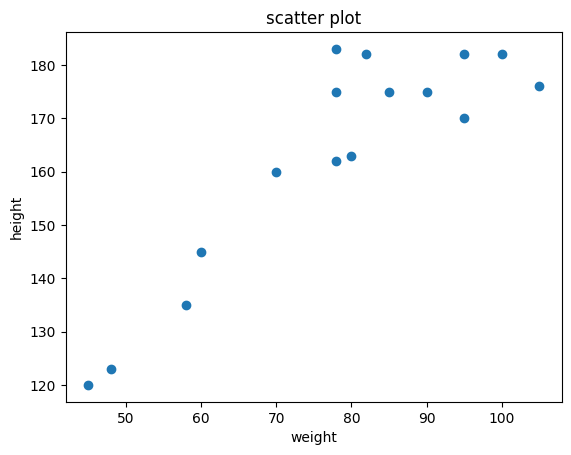

In [7]:
#scatter plot
plt.scatter(df['weight'],df['height'])
plt.xlabel('weight')
plt.ylabel('height')
plt.title('scatter plot')

In [8]:
##correlation
df.corr()

,weight,height
weight,1.000000,0.890859
height,0.890859,1.000000


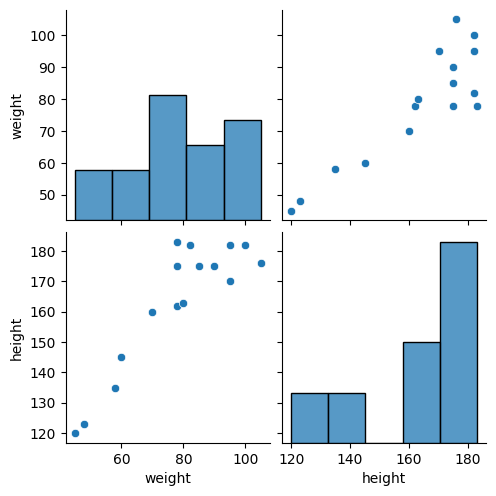

In [10]:
##seabord for visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(df)

In [17]:
##independent and dependent featured
X=df[['weight']] #### independent features should be data frame or 2 dimensions
np.array(X).shape

(16, 1)

In [21]:
X=df['weight']
Y=df['height']
 #### independent features should be data frame or 2 dimensions
np.array(X).shape

(16,)

In [23]:
Y

,height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,175


In [25]:
np.array(Y).shape

(16,)

In [28]:
##TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)


In [29]:
X_train.shape

(12,)

In [33]:
##standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()


In [37]:
X_train=sc.fit_transform(X_train.values.reshape(-1, 1))

In [38]:
X_test=sc.transform(X_test.values.reshape(-1, 1))

In [39]:
X_train

array([[ 1.14020752],
       [ 0.8278219 ],
       [ 0.8278219 ],
       [-0.23428922],
       [-2.10860295],
       [-0.23428922],
       [-0.73410621],
       [ 0.51543628],
       [ 0.01561928],
       [ 1.45259314],
       [-1.35887746],
       [-0.10933497]])

In [40]:
##apply simple linear regressin
from sklearn.linear_model import LinearRegression

In [41]:
regression=LinearRegression()

In [45]:
regression.fit(X_train,Y_train)

LinearRegression()

In [49]:
print("coefficient or slope:", regression.coef_)
print("coefficient or intercept:", regression.intercept_)

coefficient or slope: [14.33850005]
coefficient or intercept: 168.0


Text(0, 0.5, 'height')

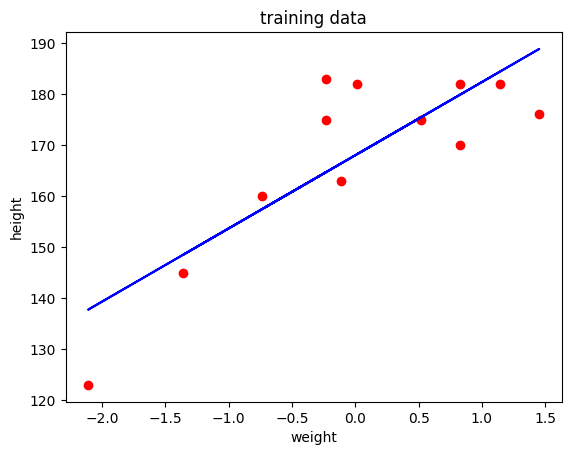

In [51]:
##plot training data best fit line
plt.scatter(X_train,Y_train,color='red')
plt.plot(X_train,regression.predict(X_train),color='blue')
plt.title('training data')
plt.xlabel('weight')
plt.ylabel('height')


In [52]:
##prediction for test data
y_pred=regression.predict(X_test)

In [53]:
##performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [54]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)


97.12470618477158
8.382898267870218
9.855186765595647


In [55]:
from sklearn.metrics import r2_score

In [57]:
score=r2_score(Y_test,y_pred)
print(score)

0.7931316162198688


In [58]:
#display adjusted r-squared
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.6896974243298033

In [59]:
##ols linear regression
import statsmodels.api as sm

In [60]:
model=sm.OLS(Y_train,X_train).fit()

In [61]:
prediction=model.predict(X_test)
print(prediction)

[-32.92168822 -21.27592096  -3.35935594   2.91144182]


In [63]:
print (model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 height   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):             -0.083
Method:                 Least Squares   F-statistic:                            0.07986
Date:                Sat, 04 Jul 2026   Prob (F-statistic):                       0.783
Time:                        06:05:27   Log-Likelihood:                         -78.535
No. Observations:                  12   AIC:                                      159.1
Df Residuals:                      11   BIC:                                      159.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------